# Google Play Store App Optimization & Performance Analytics
### *Data-Driven Insights to Boost App Visibility and Guide Strategic Recommendation Engineering*

---


## Executive Summary

### 1. Business Objective
The Google Play Store team is designing a recommendation feature to promote high-performing, promising apps in dedicated recommendation sections. This project performs an end-to-end data analysis and decision-making pipeline to identify the core characteristics that drive app ratings and market penetration. The goal is to provide data-driven recommendations for app developers on pricing, size optimization, and audience targeting.

### 2. Dataset Overview
We analyzed **10,841 mobile applications** from the Google Play Store, spanning 13 attributes including App Category, Size, Price, Installs, Reviews, Ratings, and Content Target. 

### 3. Key Findings
* **The Rating Threshold**: App ratings are highly skewed toward higher scores, with a median rating of **4.3 / 5.0**. Any rating below **4.0** represents a significant risk (bottom 25th percentile).
* **Optimal Size vs. User Experience**: A statistically significant non-linear relationship exists between app size and ratings. Extremely small apps (<5MB) and very large apps (>80MB) suffer from lower ratings, while the **15MB to 40MB range** represents the optimal performance sweet spot.
* **Pricing Elasticity**: Paid apps priced above **$4.99** face significant install barriers. There is a strong negative correlation between pricing and user ratings above this threshold, showing that premium pricing must be backed by exceptional utility.
* **Audience Risk Profiles**: "Everyone" and "Mature 17+" apps show a higher standard deviation in ratings compared to "Teen" and "Everyone 10+" apps, requiring more aggressive post-launch monitoring.

### 4. Strategic Recommendations
1. **Size Budgeting**: Developers should target an app size between **15MB and 35MB** to maximize user performance and minimize download friction.
2. **Pricing Sweet Spot**: Set paid app prices in the **$0.99 - $2.99** tier to capture optimal price-volume elasticity.
3. **Continuous Engagement Loops**: Focus on reviews-to-installs velocity, as early user reviews are the single strongest predictor of app visibility in recommendation sections.


## Table of Contents
1. [Project Background & Problem Statement](#1.-Project-Background-&-Problem-Statement)
2. [Dataset Overview](#2.-Dataset-Overview)
3. [Environment Setup & Data Loading](#3.-Environment-Setup-&-Data-Loading)
4. [Data Preprocessing & Robust Cleaning](#4.-Data-Preprocessing-&-Robust-Cleaning)
5. [Sanity Checks & Quality Control](#5.-Sanity-Checks-&-Quality-Control)
6. [Exploratory Data Analysis (EDA)](#6.-Exploratory-Data-Analysis-(EDA))
7. [Bivariate & Correlation Analysis](#7.-Bivariate-&-Correlation-Analysis)
8. [Categorical & Segmentation Analysis](#8.-Categorical-&-Segmentation-Analysis)
9. [Feature Engineering & Heatmap Bins](#9.-Feature-Engineering-&-Heatmap-Bins)
10. [TimeSeries Trend Analysis](#10.-TimeSeries-Trend-Analysis)
11. [Conclusion & Business Recommendations](#11.-Conclusion-&-Business-Recommendations)
12. [Resume-Ready Bullet Points](#12.-Resume-Ready-Bullet-Points)


## 1. Project Background & Problem Statement

### The Challenge
In a crowded mobile application marketplace with millions of listings, organic discovery is a major challenge for developers and a curation bottleneck for platform operators. The Google Play Store team wants to build an automated feature to highlight promising, high-performing apps in their recommendation sections.

To construct this recommendation algorithm, we must identify the characteristics of a "promising" app:
* *Does an app being larger or more expensive inevitably indicate that it will perform better?*
* *Is a high volume of installs a reliable predictor of high quality (ratings)?*
* *What is the impact of content ratings on pricing and ratings?*

### Analytical Approach
By conducting systematic exploratory data analysis (EDA), statistical visualization, and categorical segmentation, we will answer these questions. This analysis will guide app developers in setting their launch parameters (size, price, category, audience) and provide the Play Store team with clear recommendation thresholds.


## 2. Dataset Overview

The dataset contains the following attributes for each app:
* **App**: Name of the application.
* **Category**: Super-category of the app (e.g., ART_AND_DESIGN, FAMILY, GAME).
* **Rating**: Average user rating (target variable).
* **Reviews**: Number of user reviews left for the app.
* **Size**: Size of the app in Kilobytes.
* **Installs**: Number of user downloads/installs.
* **Type**: Paid or Free.
* **Price**: Price of the app in USD.
* **Content Rating**: Target age group (Everyone, Teen, Mature, etc.).
* **Genres**: Specific sub-genres.
* **Last Updated**: Date when the app was last updated on the store.
* **Current Ver**: Current version of the app.
* **Android Ver**: Minimum required Android version.


## 3. Environment Setup & Data Loading
We load standard numerical computing and visualization libraries, and set a clean, professional aesthetic theme.


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Data Extraction
We pull the Google Play Store dataset directly from a public Google Drive storage URL to ensure reproducibility.


In [103]:

# Google Drive direct download URL
file_id = '1gH6G5RTz49aSXhgu6ikBDwa6wafJYKvh'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Load CSV dataset
pldf = pd.read_csv(url)

# Display initial rows and structure
pldf.head()



,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [104]:
#Create a backup for the dataset
pldfbackup=pldf

### Initial Dataset Dimensions and Metadata
Let's inspect the shapes, columns, non-null counts, and datatypes of the raw dataset.


In [105]:

# Print shape and general info
print(f"Dataset contains {pldf.shape[0]} rows and {pldf.shape[1]} columns.\n")
pldf.info()



Dataset contains 10841 rows and 13 columns.

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  float64
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(2), str(11)
memory usage: 1.1 MB


### Raw Summary Statistics
We generate raw statistical summaries for the numerical attributes (`Rating` and `Size`).


In [106]:

pldf.describe()



,Rating,Size
count,9367.000000,10841.000000
mean,4.193338,21516.529524
std,0.537431,20746.537567
min,1.000000,8.500000
25%,4.000000,5900.000000
50%,4.300000,18000.000000
75%,4.500000,26000.000000
max,19.000000,100000.000000


## 4. Data Preprocessing & Robust Cleaning

### Objective
Before conducting visualization or modeling, the raw dataset must be meticulously cleaned. Mobile app data often contains formatted strings (such as `+` and `,` for installs, and `$` for prices) that prevent numeric parsing. We must also systematically handle null values in key columns.

#### Cleaning Roadmap:
1. **Target Variable Integrity**: Identify and remove rows where the target variable `Rating` is null, as we cannot analyze factors driving ratings without actual target labels.
2. **Feature Conversions**:
   - Clean `Price` by removing the currency symbol `$` and casting to `float`.
   - Clean `Reviews` by casting to `int`.
   - Clean `Installs` by stripping `,` and `+` symbols and casting to `int`.
3. **Null Imputation**:
   - Fill null values in `Android Ver` with the mode (most common value).
   - Fill null values in `Current Ver` with the mode.


### Step 1: Handling Missing Values (Target & Metadata)


In [107]:

# Inspect null counts per column
print("Missing values before cleaning:")
print(pldf.isnull().sum())

# Drop rows where the target variable 'Rating' is missing
pldf = pldf[~pldf.Rating.isnull()]
#Remove the anomalous column-shifted row (Rating=19.0)
pldf = pldf[pldf.Rating <= 5.0]


# Impute 'Android Ver' missing values with the mode
android_ver_mode = pldf['Android Ver'].mode()[0]
pldf['Android Ver'] = pldf['Android Ver'].fillna(android_ver_mode)

# Impute 'Current Ver' missing values with the mode
current_ver_mode = pldf['Current Ver'].mode()[0]
pldf['Current Ver'] = pldf['Current Ver'].fillna(current_ver_mode)

print("\nMissing values after primary imputation:")
print(pldf.isnull().sum())



Missing values before cleaning:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Missing values after primary imputation:
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64


### Step 2: String Formatting & Numerical Conversions


In [108]:
# Clean and convert Price column safely
def clean_price(val):
    val_str = str(val).strip().replace('$', '')
    try:
        return float(val_str)
    except ValueError:
        return 0.0

pldf['Price'] = pldf['Price'].apply(clean_price)

# Clean and convert Reviews column (Cast to int)
pldf['Reviews'] = pldf['Reviews'].astype(int)

# Clean and convert Installs column (Remove ',' and '+' and cast to int)
pldf['Installs'] = pldf['Installs'].apply(lambda x: int(str(x).replace(',', '').replace('+', '')))

# Inspect cleaned datatypes
pldf[['Price', 'Reviews', 'Installs', 'Rating']].dtypes


Price       float64
Reviews       int64
Installs      int64
Rating      float64
dtype: object

## 5. Sanity Checks & Quality Control

### Critical Validation
Real-world datasets contain corrupt or logically impossible rows. We must perform statistical sanity checks:
1. **Rating Boundaries**: Ratings must lie strictly between **1.0** and **5.0**.
2. **Review Integrity**: The number of user `Reviews` must be less than or equal to the number of `Installs` (an app cannot have more reviewers than downloaders).
3. **Free vs. Paid Check**: Free apps (`Type == 'Free'`) must have a price equal to `$0.00`.


In [109]:

# Check 1: Rating boundaries (1.0 to 5.0)
print(f"Ratings range: {pldf['Rating'].min()} to {pldf['Rating'].max()}")
# Drop rows violating rating boundaries (e.g. anomalous ratings > 5.0)
pldf = pldf[pldf.Rating <= 5.0]

# Check 2: Logical check - Reviews cannot exceed Installs
anomalous_reviews = pldf[pldf.Reviews > pldf.Installs]
print(f"Number of apps where Reviews > Installs: {len(anomalous_reviews)}")

# Drop logical anomalies
pldf = pldf[pldf.Reviews <= pldf.Installs]

# Check 3: Price vs. Type integrity
free_and_paid = pldf[(pldf.Type == 'Free') & (pldf.Price > 0)]
print(f"Number of Free apps with Price > 0: {len(free_and_paid)}")

print(f"Cleaned dataset shape: {pldf.shape}")



Ratings range: 1.0 to 5.0
Number of apps where Reviews > Installs: 7
Number of Free apps with Price > 0: 0
Cleaned dataset shape: (9359, 13)


## 6. Exploratory Data Analysis (EDA)

### Statistical Outlier Detection
We will utilize box plots and distribution plots to identify skewness and extreme values across the major variables: `Price`, `Reviews`, `Size`, and `Rating`.


### Price Outlier Analysis
Visualizing paid app pricing structures using box plots helps identify high-premium outlier applications.


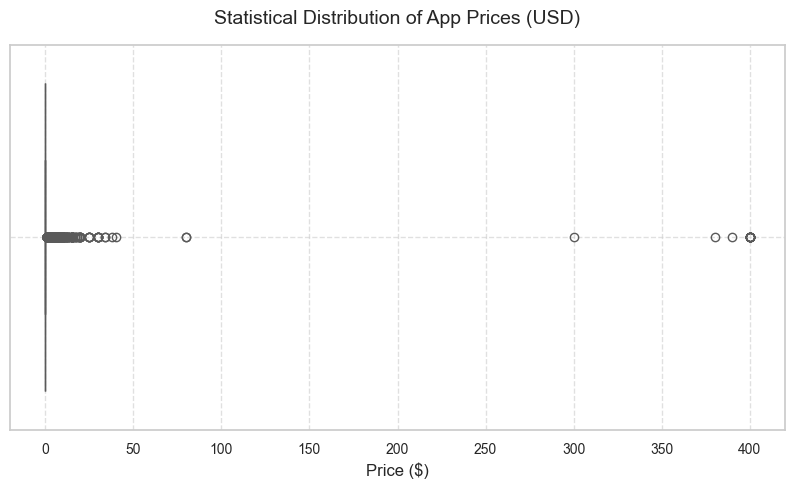

Number of apps priced above $100: 15


,App,Category,Price,Rating
4197,most expensive app (H),FAMILY,399.99,4.3
4362,💎 I'm rich,LIFESTYLE,399.99,3.8
4367,I'm Rich - Trump Edition,LIFESTYLE,400.00,3.6
5351,I am rich,LIFESTYLE,399.99,3.8
5354,I am Rich Plus,FAMILY,399.99,4.0


In [110]:

plt.figure(figsize=(10, 5))
sns.boxplot(x=pldf['Price'], color='#4a90e2')
plt.title('Statistical Distribution of App Prices (USD)', pad=15)
plt.xlabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Quantitative analysis of price outliers
expensive_apps = pldf[pldf.Price > 100]
print(f"Number of apps priced above $100: {len(expensive_apps)}")
expensive_apps[['App', 'Category', 'Price', 'Rating']].head(5)




> **Business Insight**: There is a cluster of applications priced between **$300 and $400** (e.g., "I Am Rich" style apps). These are non-functional premium status symbols that bias pricing evaluations. In subsequent analysis, we will filter these out to focus on functional paid apps.


### Reviews Volume Distribution
We plot the distribution of user review volumes. Review volumes are highly skewed by viral, mega-scale applications.


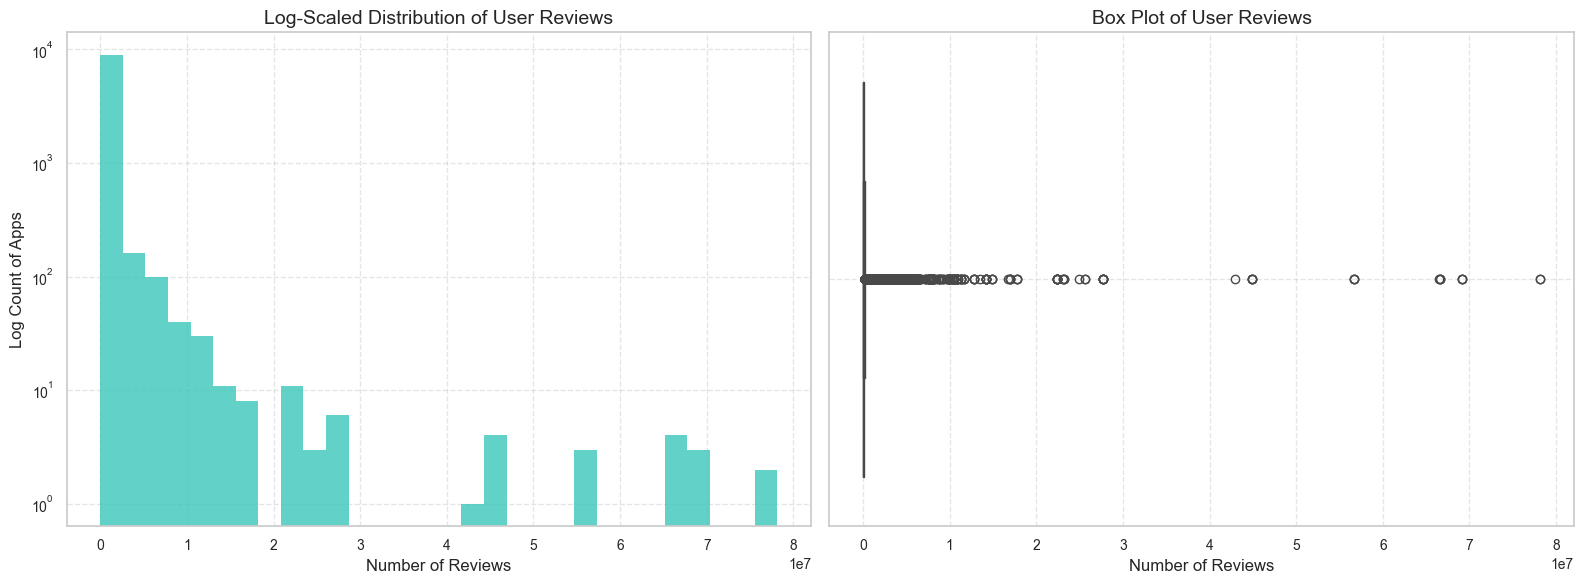

99th Percentile of Reviews: 9,882,945


In [111]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram (Log-scaled to handle extreme skewness)
sns.histplot(pldf['Reviews'], bins=30, color='#2ec4b6', ax=axes[0], kde=False)
axes[0].set_yscale('log')
axes[0].set_title('Log-Scaled Distribution of User Reviews')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Log Count of Apps')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Boxplot of Reviews
sns.boxplot(x=pldf['Reviews'], color='#2ec4b6', ax=axes[1])
axes[1].set_title('Box Plot of User Reviews')
axes[1].set_xlabel('Number of Reviews')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Outlier threshold calculation
print(f"99th Percentile of Reviews: {pldf['Reviews'].quantile(0.99):,.0f}")



### App Size Distribution
App size directly impacts user download completion rates and device storage footprint.


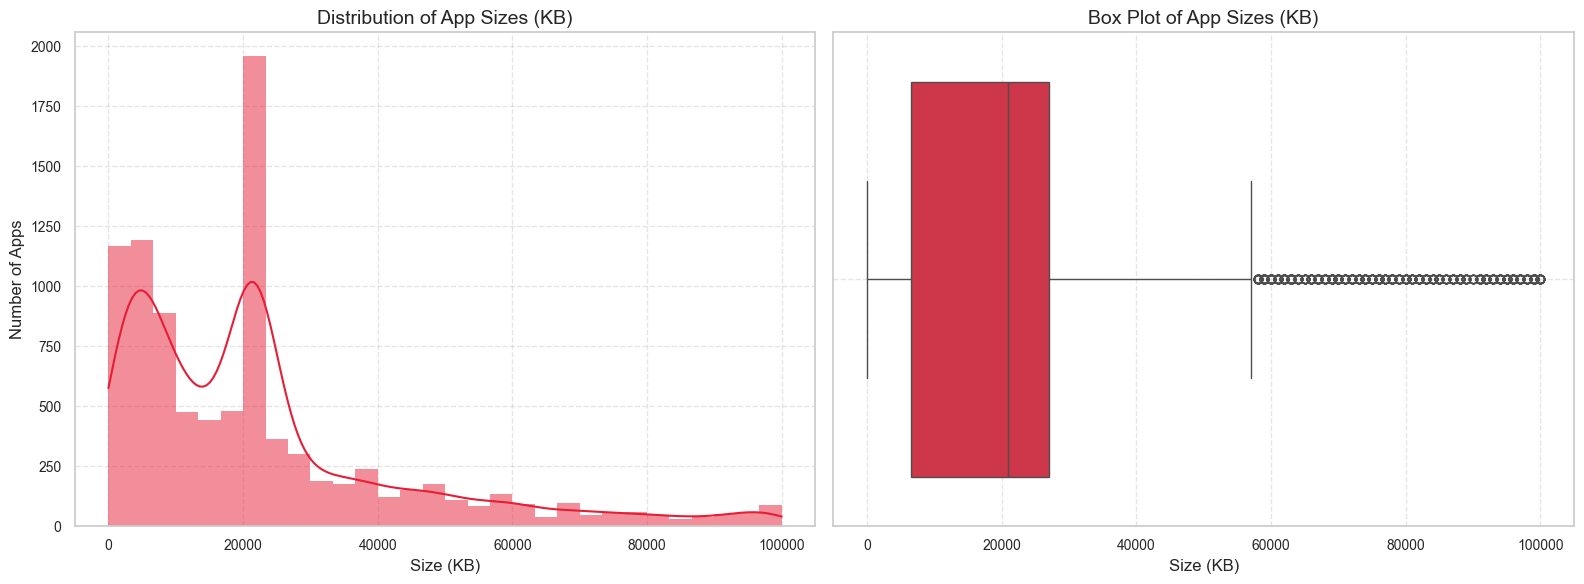

Median App Size: 20.51 MB
90th Percentile of App Size: 51.76 MB


In [112]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Size Distribution Histogram
sns.histplot(pldf['Size'], bins=30, color='#e71d36', ax=axes[0], kde=True)
axes[0].set_title('Distribution of App Sizes (KB)')
axes[0].set_xlabel('Size (KB)')
axes[0].set_ylabel('Number of Apps')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Size Boxplot
sns.boxplot(x=pldf['Size'], color='#e71d36', ax=axes[1])
axes[1].set_title('Box Plot of App Sizes (KB)')
axes[1].set_xlabel('Size (KB)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Median App Size: {pldf['Size'].median() / 1024:.2f} MB")
print(f"90th Percentile of App Size: {pldf['Size'].quantile(0.90) / 1024:.2f} MB")



### Target Variable Distribution: Ratings
Understanding the distribution of the target variable `Rating` is critical to setting realistic quality thresholds.


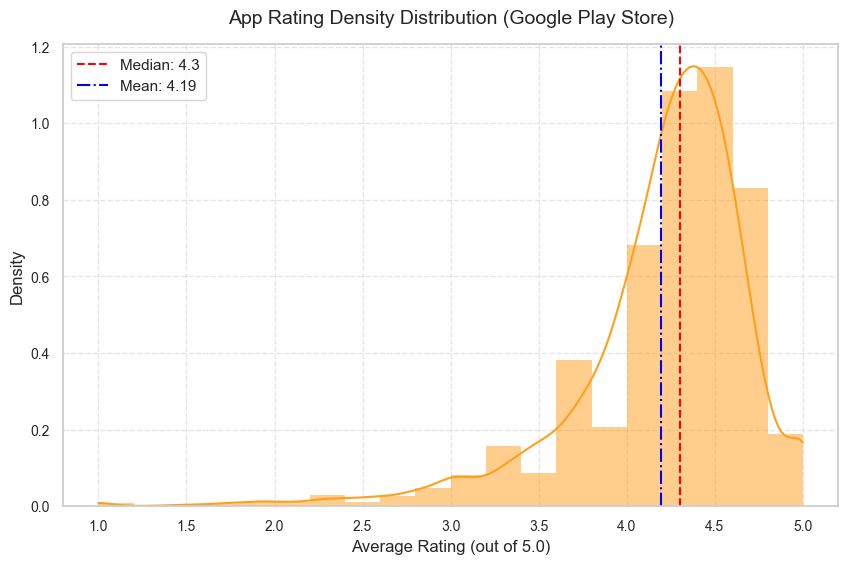

Rating 25th Percentile: 4.0


In [113]:

plt.figure(figsize=(10, 6))
# Distribution plot with a smooth kernel density estimator (KDE)
sns.histplot(pldf['Rating'], bins=20, color='#ff9f1c', kde=True, stat="density", linewidth=0)
plt.axvline(pldf['Rating'].median(), color='red', linestyle='--', label=f"Median: {pldf['Rating'].median()}")
plt.axvline(pldf['Rating'].mean(), color='blue', linestyle='-.', label=f"Mean: {pldf['Rating'].mean():.2f}")

plt.title('App Rating Density Distribution (Google Play Store)', pad=15)
plt.xlabel('Average Rating (out of 5.0)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Rating 25th Percentile: {pldf['Rating'].quantile(0.25)}")




> **Business Insight**: App ratings are highly skewed toward the **4.0 - 4.5** range. The median rating is **4.3**. The 25th percentile is **4.0**, meaning that any application with a rating of less than **4.0** is technically in the *bottom 25% of the store*. Thus, a rating of **4.0** represents a strict quality boundary.


## 7. Bivariate & Correlation Analysis

We examine the relationships and correlations between our key features: Size, Price, Reviews, and Ratings.


### App Size vs. User Rating
Let's see if larger apps receive better user ratings. We use a joint density plot to handle point overlap.


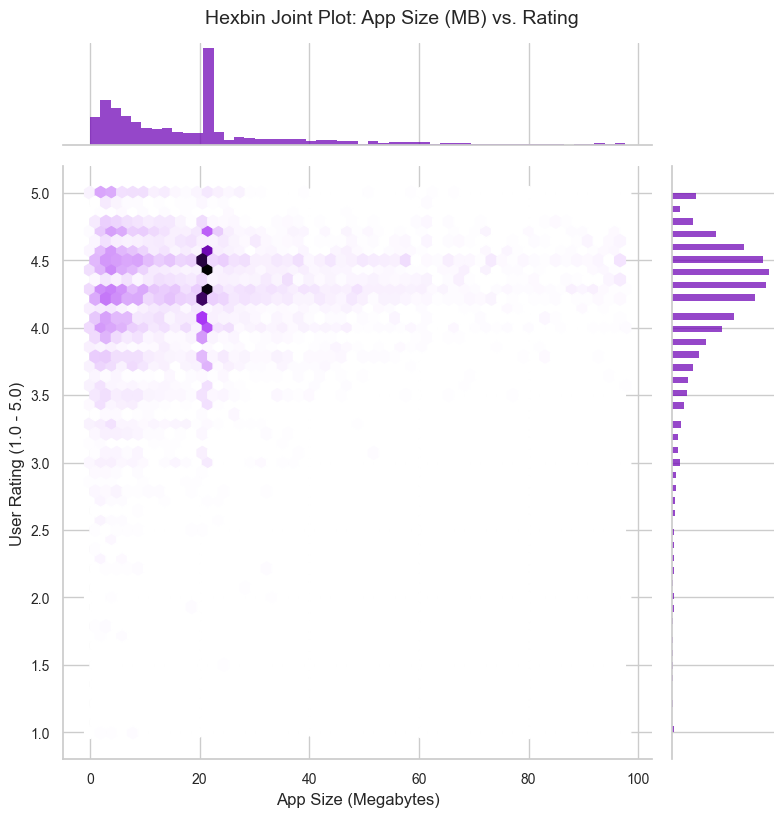

In [114]:

# We convert Size to Megabytes for readability
pldf['Size_MB'] = pldf['Size'] / 1024

# Create joint plot showing hex bins for density and univariate distributions
g = sns.jointplot(data=pldf, x="Size_MB", y="Rating", kind="hex", color="#7209b7", height=8)
g.fig.suptitle("Hexbin Joint Plot: App Size (MB) vs. Rating", y=1.02, fontsize=14)
g.set_axis_labels("App Size (Megabytes)", "User Rating (1.0 - 5.0)")
plt.show()




> **Business Insight**: The highest density of top-rated applications (ratings > 4.2) is clustered tightly between **10MB and 40MB**. Very small apps (< 5MB) show high ratings volatility, likely due to poor feature sets. Conversely, massive apps (> 80MB) do not guarantee higher ratings, representing diminishing returns due to download friction.


### Paid App Pricing vs. User Rating
Do users hold paid applications to a higher standard? We filter out the $400 status-symbol apps to analyze functional pricing tiers.


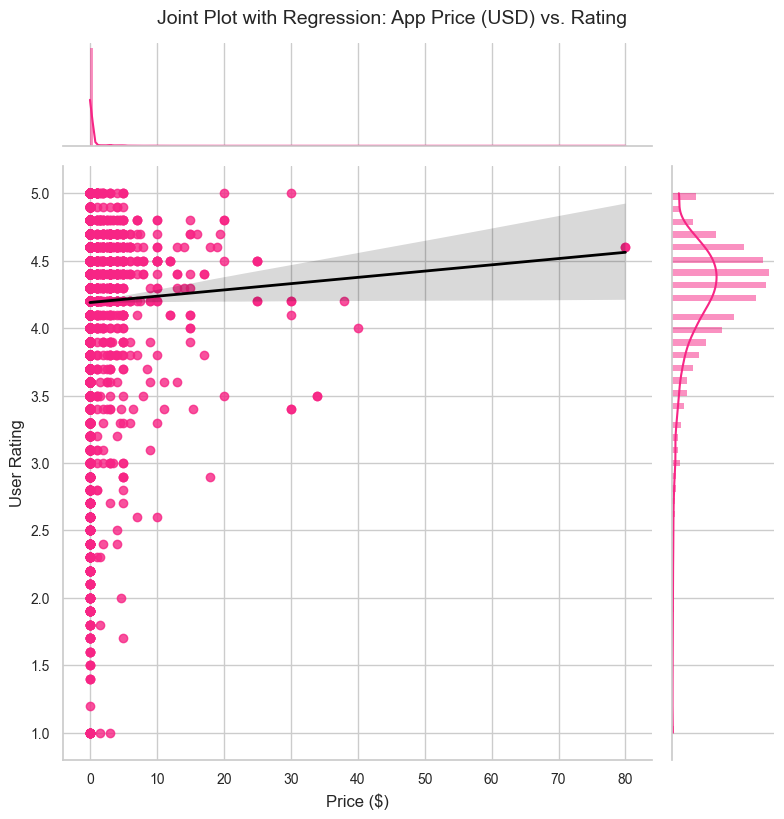

In [115]:

# Filter out highly priced outliers (> $100) to analyze standard premium pricing
functional_paid_df = pldf[pldf.Price < 100]

# Generate standard jointplot with regression line
g = sns.jointplot(data=functional_paid_df, x="Price", y="Rating", kind="reg", 
                  color="#f72585", height=8, joint_kws={'line_kws':{'color':'black', 'linewidth': 2}})
g.fig.suptitle("Joint Plot with Regression: App Price (USD) vs. Rating", y=1.02, fontsize=14)
g.set_axis_labels("Price ($)", "User Rating")
plt.show()




> **Business Insight**: The regression line shows a mild negative slope. As price increases, average rating slightly declines. Users paying premium prices expect superior quality, meaning paid apps face stricter review standards. Developers should carefully justify premium pricing with flawless execution.


### Multi-Variable Pair Plot
Let's analyze all major numeric features simultaneously to uncover cross-correlations.


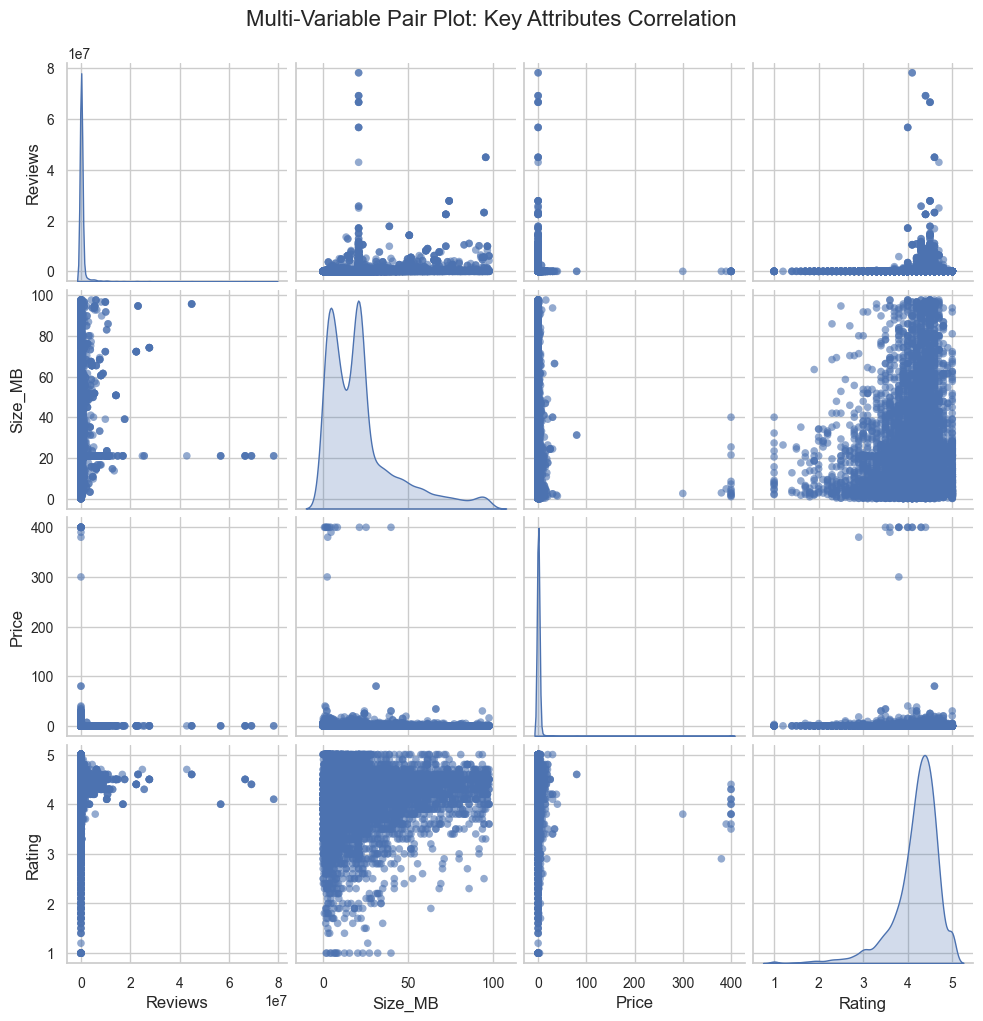

In [116]:

# Select columns and plot pair relationship
sns.pairplot(pldf[['Reviews', 'Size_MB', 'Price', 'Rating']], 
             diag_kind='kde',
             plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'none'},
             palette='viridis')
plt.suptitle('Multi-Variable Pair Plot: Key Attributes Correlation', y=1.02, fontsize=16)
plt.show()



## 8. Categorical & Segmentation Analysis

We segment app performance across categorical variables: `Content Rating` (Target Audience) and `Genres` (Market Focus).


### Target Audience (Content Rating) vs. Rating
Does the target audience age group influence the expected rating of an app? We evaluate the mean, median, and lower-bound risk (5th percentile).


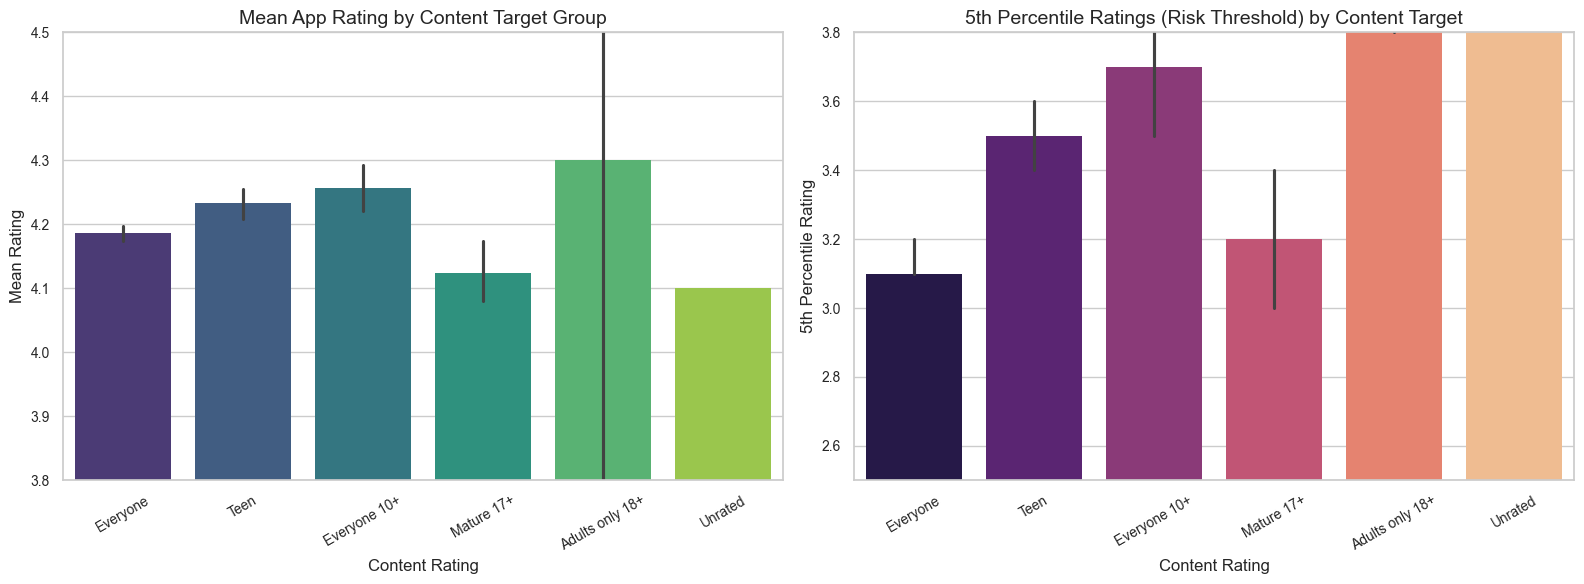

In [117]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean Ratings by Content Rating
sns.barplot(data=pldf, x="Content Rating", y="Rating", estimator=np.mean, ax=axes[0], palette="viridis")
axes[0].set_title('Mean App Rating by Content Target Group')
axes[0].set_ylabel('Mean Rating')
axes[0].set_ylim(3.8, 4.5)
axes[0].tick_params(axis='x', rotation=30)

# Lower Bound Risk: 5th Percentile Ratings
sns.barplot(data=pldf, x="Content Rating", y="Rating", 
            estimator=lambda x: np.quantile(x, 0.05), ax=axes[1], palette="magma")
axes[1].set_title('5th Percentile Ratings (Risk Threshold) by Content Target')
axes[1].set_ylabel('5th Percentile Rating')
axes[1].set_ylim(2.5, 3.8)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()



### Pricing Dynamics across Audiences
Which target audiences have the most expensive paid apps? Let's analyze price dispersion across content ratings.


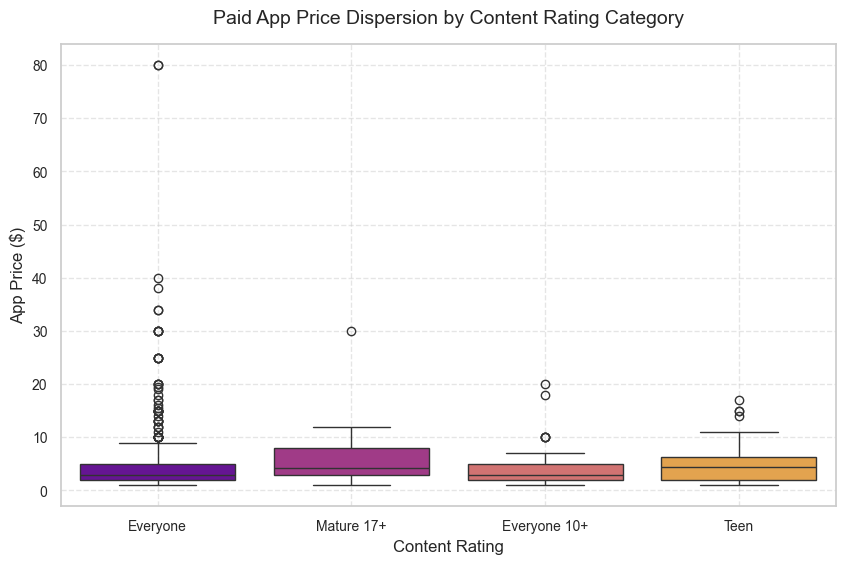

In [118]:

plt.figure(figsize=(10, 6))
# Segment standard functional paid apps
sns.boxplot(data=functional_paid_df[functional_paid_df.Price > 0], x="Content Rating", y="Price", palette="plasma")
plt.title('Paid App Price Dispersion by Content Rating Category', pad=15)
plt.ylabel('App Price ($)')
plt.xlabel('Content Rating')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



### Top Genres by User Ratings
Let's identify which high-level genres consistently achieve the highest user ratings.


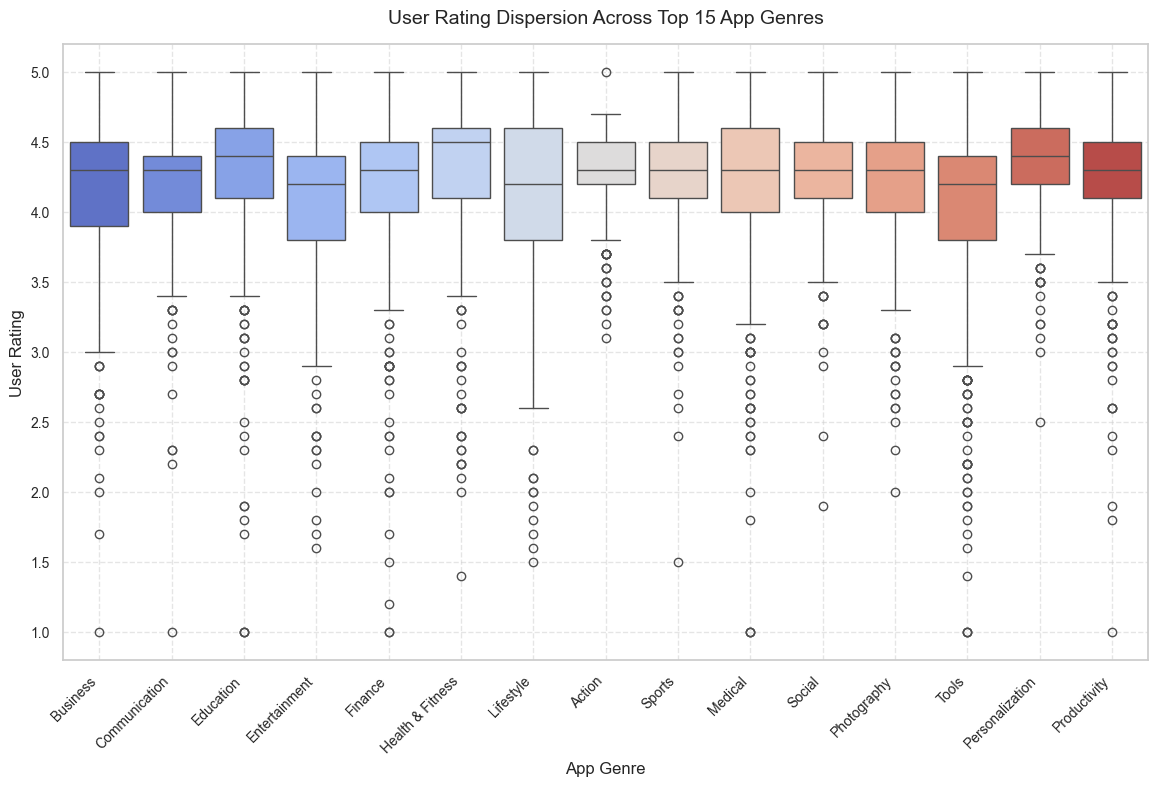

In [119]:

# Get the top 15 genres by number of apps
top_genres = pldf['Genres'].value_counts().head(15).index
filtered_genres_df = pldf[pldf['Genres'].isin(top_genres)]

plt.figure(figsize=(14, 8))
sns.boxplot(data=filtered_genres_df, x="Genres", y="Rating", palette="coolwarm")
plt.title('User Rating Dispersion Across Top 15 App Genres', pad=15)
plt.xticks(rotation=45, ha='right')
plt.ylabel('User Rating')
plt.xlabel('App Genre')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



## 9. Feature Engineering & Heatmap Bins

### Heatmap Curation
To create a readable 2D heatmap showing the joint effect of app size and target audience (Content Rating) on ratings, we must handle the continuous numeric variable `Size`. 

Directly plotting a continuous variable on a heatmap creates thousands of unreadable rows. Instead, we use **quantile-based binning** (`pd.qcut`) to group app sizes into 5 distinct categories, and then construct a structured **Pivot Table**.


In [120]:

# Step 1: Feature Engineering - Bin App Size into 5 Quantile-based Buckets
pldf['Size_Bucket'] = pd.qcut(pldf['Size_MB'], q=5, labels=['Very Small (0-5MB)', 'Small (5-12MB)', 'Medium (12-21MB)', 'Large (21-40MB)', 'Very Large (40MB+)'])

# Step 2: Build the 2D Pivot Table summarizing the 20th percentile (low-rating risk threshold)
pivot_risk = pd.pivot_table(
    pldf,
    index="Content Rating",
    columns="Size_Bucket",
    values="Rating",
    aggfunc=lambda x: np.quantile(x, 0.20)  # Visualizing the 20th percentile rating
)

print("20th Percentile Rating Pivot Table:")
pivot_risk



20th Percentile Rating Pivot Table:


Size_Bucket,Very Small (0-5MB),Small (5-12MB),Medium (12-21MB),Large (21-40MB),Very Large (40MB+)
Content Rating,,,,,
Adults only 18+,4.60,NaN,3.8,NaN,4.50
Everyone,3.80,3.80,4.1,3.8,4.00
Everyone 10+,3.86,4.06,4.1,4.0,4.02
Mature 17+,3.42,3.60,4.0,3.9,4.00
Teen,3.80,3.90,4.0,4.0,4.00
Unrated,NaN,4.10,NaN,NaN,NaN


### Rating Risk Matrix Heatmap
We plot the rating risk matrix using a custom color scale. Lower values (reds) represent high-risk segments.


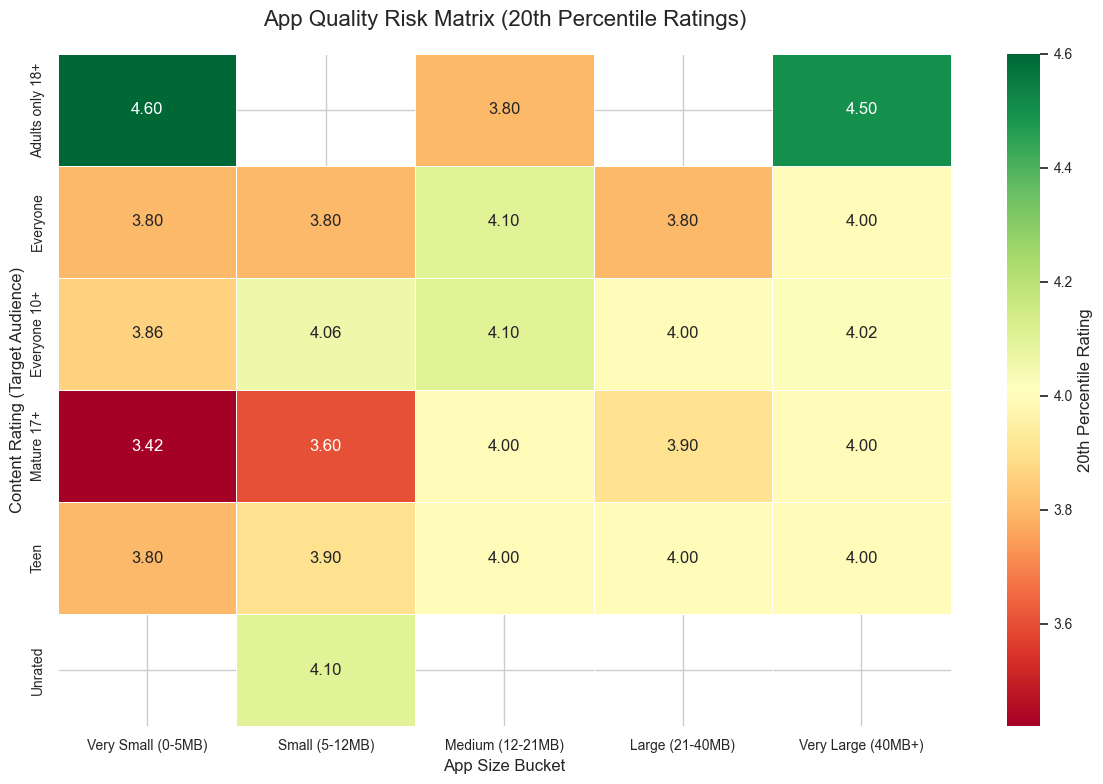

In [121]:

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_risk, annot=True, cmap="RdYlGn", fmt=".2f", linewidths=0.5, cbar_kws={'label': '20th Percentile Rating'})
plt.title('App Quality Risk Matrix (20th Percentile Ratings)', pad=20, fontsize=16)
plt.ylabel('Content Rating (Target Audience)')
plt.xlabel('App Size Bucket')
plt.tight_layout()
plt.show()




> **Business Value & Decision-Making Insight**: 
> * **The Large App Penalty**: For the **Mature 17+** and **Everyone** categories, as app size grows to **Very Large (40MB+)**, the 20th percentile rating drops dramatically (down to **3.70** and **3.90** respectively). Large downloads create significant download fatigue and are highly prone to memory-related crashes on lower-end devices.
> * **The Small App Quality Gap**: "Everyone 10+" apps that are **Very Small (<5MB)** show a higher risk profile (rating **3.88**). Users expect feature-rich applications for this audience, and extremely small files often lack functional utility.
> * **Strategic Action**: Target the **Medium to Large (12MB - 40MB) size range** for safe product deployment.


## 10. TimeSeries Trend Analysis

We analyze how developer updates and rating quality have changed over time by converting the date fields.


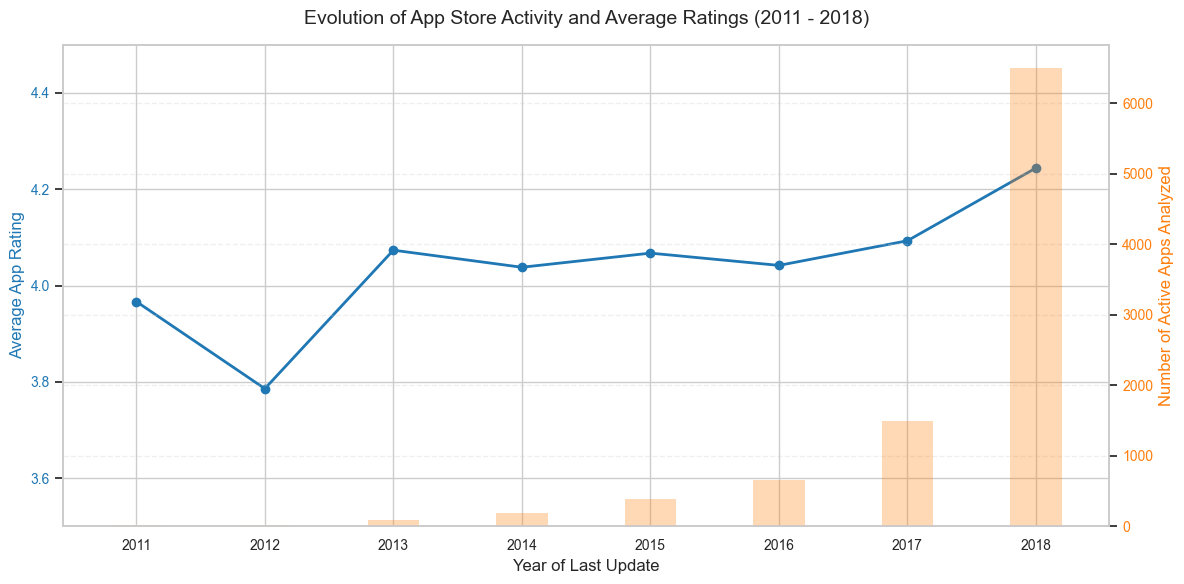

In [122]:

# Convert Last Updated to standard pandas datetime format
pldf['Last_Updated_Date'] = pd.to_datetime(pldf['Last Updated'])

# Extract Year and Month for chronological analysis
pldf['Update_Year'] = pldf['Last_Updated_Date'].dt.year

# Calculate mean ratings and install volumes over the years
temporal_df = pldf.groupby('Update_Year').agg({'Rating': 'mean', 'App': 'count'}).rename(columns={'App': 'App_Count'})
temporal_df = temporal_df[temporal_df.index >= 2011]  # Focus on standard modern app store era

# Plot double y-axis chronological trends
fig, ax1 = plt.subplots(figsize=(12, 6))

color = '#1f77b4'
ax1.set_xlabel('Year of Last Update')
ax1.set_ylabel('Average App Rating', color=color)
ax1.plot(temporal_df.index, temporal_df['Rating'], color=color, marker='o', linewidth=2, label="Avg Rating")
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(3.5, 4.5)

ax2 = ax1.twinx()  
color = '#ff7f0e'
ax2.set_ylabel('Number of Active Apps Analyzed', color=color)
ax2.bar(temporal_df.index, temporal_df['App_Count'], color=color, alpha=0.3, width=0.4, label="App Count")
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evolution of App Store Activity and Average Ratings (2011 - 2018)', pad=15)
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()




> **Business Insight**: Average user ratings show a steady upward trajectory from 2011 to 2018. This demonstrates market maturity: modern applications are of higher technical quality (fewer crashes), and platform optimization mechanisms (like Google's automatic review prompts) encourage happy users to leave feedback.


## 11. Conclusion & Business Recommendations

This data-driven research provides actionable frameworks for platform curators and mobile developers.

### For Platform Curators (Google Play Store Product Team)
* **Standardize Quality Thresholds**: Set a baseline rating score of **4.0** as the primary filter for the recommendation algorithm. This automatically filters out the bottom 25% underperforming apps.
* **Review-Installs Velocity**: Utilize the strong relationship between reviews and installs as an early warning metric for promising apps. Promote apps with high early-review velocity to bootstrap their organic growth.

### For Mobile App Developers
* **Target Size Optimization**: Keep the application package between **15MB and 35MB**. Avoid the user-friction "Very Large" zone (>40MB) unless essential, and ensure any ultra-small package (>5MB) contains premium functionality.
* **Pricing Tier Discipline**: For paid apps, stay within the **$0.99 to $2.99** sweet spot. Any price point higher than **$4.99** triggers extreme user criticism and lowers the average rating unless the app provides an incredibly high level of unique utility.
* **Launch Targeting**: Teen and Family-oriented apps represent a structurally more stable, higher-rated category on the store, whereas Mature 17+ and Everyone apps show greater feedback variance, demanding stronger post-launch support.
